In [ ]:
pip install yfinance

In [ ]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=39e1872880c9f3047af8561aa6a1e71cdbc4c12d6066091aafa7cc9f804bd8af
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta  # Technical Analysis library
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Define the stock ticker (TSLA in this case)
ticker = 'TSLA'

# Download data from 2010-01-01 to the most recent available date
new_data = yf.download(ticker, start='2010-01-01', end='2024-01-01')

# Preview the new data
print(new_data.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          TSLA      TSLA      TSLA      TSLA       TSLA
Date                                                         
2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500
2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500
2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500


In [ ]:
# Access the 'Close' column using the correct multi-level index
close_prices = new_data[('Close', ticker)]

# Check if it is a 1D pandas Series
print(close_prices.shape)

(3400,)


In [ ]:
# Access the 'Close' column using the correct multi-level index
close_prices = new_data[('Close', ticker)]

# Step 3: Calculate technical indicators
# Calculate 20-period SMA (Simple Moving Average)
new_data[('SMA_20', '')] = new_data[('Close', ticker)].rolling(window=20).mean()

# Calculate 20-period EMA (Exponential Moving Average)
new_data[('EMA_20', '')] = new_data[('Close', ticker)].ewm(span=20, adjust=False).mean()

# Calculate 14-period RSI (Relative Strength Index)
new_data[('RSI', '')] = ta.momentum.RSIIndicator(close_prices, window=14).rsi()

# Calculate Bollinger Bands (Upper and Lower)
new_data[('Bollinger_Upper', '')] = new_data[('SMA_20', '')] + 2 * new_data[('Close', ticker)].rolling(window=20).std()
new_data[('Bollinger_Lower', '')] = new_data[('SMA_20', '')] - 2 * new_data[('Close', ticker)].rolling(window=20).std()

# Handle NaN values caused by rolling calculations (forward fill or drop)
new_data.ffill(inplace=True)

new_data.dropna(inplace=True)  # Alternatively, drop rows with NaN values

# Preview the data with the new technical indicators
print(new_data.head())

Price          Close      High       Low      Open    Volume    SMA_20  \
Ticker          TSLA      TSLA      TSLA      TSLA      TSLA             
Date                                                                     
2010-07-27  1.370000  1.412000  1.350667  1.394000   9295500  1.324767   
2010-07-28  1.381333  1.393333  1.367333  1.370000   7008000  1.314200   
2010-07-29  1.356667  1.392000  1.333333  1.384667   9240000  1.302600   
2010-07-30  1.329333  1.362667  1.303333  1.346667   6403500  1.295867   
2010-08-02  1.394667  1.398000  1.355333  1.366667  10771500  1.301600   

Price         EMA_20        RSI Bollinger_Upper Bollinger_Lower  
Ticker                                                           
Date                                                             
2010-07-27  1.375710  47.753430        1.630962        1.018572  
2010-07-28  1.376245  48.821692        1.595001        1.033399  
2010-07-29  1.374381  46.588938        1.553205        1.051995  
2010-07-30 

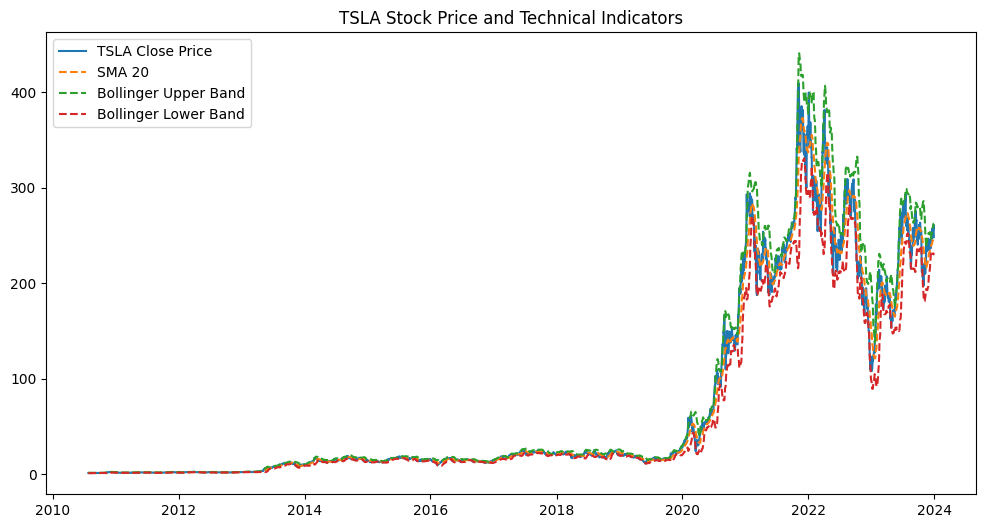

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(new_data['Close'], label='TSLA Close Price')
plt.plot(new_data['SMA_20'], label='SMA 20', linestyle='--')
plt.plot(new_data['Bollinger_Upper'], label='Bollinger Upper Band', linestyle='--')
plt.plot(new_data['Bollinger_Lower'], label='Bollinger Lower Band', linestyle='--')
plt.legend(loc='best')
plt.title('TSLA Stock Price and Technical Indicators')
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Define the columns to normalize
features_to_normalize = ['Open', 'High', 'Low', 'Close', 'Volume',
                         'SMA_20', 'EMA_20', 'RSI', 'Bollinger_Upper', 'Bollinger_Lower']

# Create a MinMaxScaler instance
scaler = MinMaxScaler()

# Normalize the selected features
new_data[features_to_normalize] = scaler.fit_transform(new_data[features_to_normalize])

# Preview the normalized data
print(new_data.head())

Price          Close      High       Low      Open    Volume    SMA_20  \
Ticker          TSLA      TSLA      TSLA      TSLA      TSLA             
Date                                                                     
2010-07-27  0.000481  0.000529  0.000473  0.000505  0.008241  0.000106   
2010-07-28  0.000509  0.000484  0.000514  0.000447  0.005733  0.000078   
2010-07-29  0.000448  0.000481  0.000430  0.000483  0.008180  0.000047   
2010-07-30  0.000382  0.000410  0.000356  0.000390  0.005071  0.000029   
2010-08-02  0.000541  0.000495  0.000485  0.000439  0.009859  0.000044   

Price         EMA_20       RSI Bollinger_Upper Bollinger_Lower  
Ticker                                                          
Date                                                            
2010-07-27  0.000222  0.401749        0.000552        0.000000  
2010-07-28  0.000224  0.415509        0.000470        0.000045  
2010-07-29  0.000219  0.386749        0.000375        0.000101  
2010-07-30  0.000

In [ ]:
def create_sequences(data, sequence_length, target_column='Close'):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        # Select the features (excluding 'Date' and target column)
        features = data.iloc[i-sequence_length:i].drop(columns=[target_column]).values
        X.append(features)
        y.append(data.iloc[i][target_column])
    return np.array(X), np.array(y)

# Set sequence length (e.g., 60 days)
sequence_length = 60

# Create sequences for the model (e.g., 'Close' as target)
X, y = create_sequences(new_data, sequence_length, target_column='Close')

# Check shapes of features and target
print(f"Features Shape: {X.shape}, Target Shape: {y.shape}")

Features Shape: (3321, 60, 9), Target Shape: (3321, 1)


In [ ]:
from sklearn.model_selection import train_test_split

# Initial split into training+validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Further split training+validation into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.18, random_state=42)  # 18% of 85% ≈ 15%

# Print shapes of the splits
print(f"Training Data: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Validation Data: X_val={X_val.shape}, y_val={y_val.shape}")
print(f"Testing Data: X_test={X_test.shape}, y_test={y_test.shape}")

Training Data: X_train=(2314, 60, 9), y_train=(2314, 1)
Validation Data: X_val=(508, 60, 9), y_val=(508, 1)
Testing Data: X_test=(499, 60, 9), y_test=(499, 1)


In [ ]:
np.savez('processed_tsla_data.npz', X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test, X_val=X_val, y_val=y_val)

In [ ]:
# Load preprocessed data
import numpy as np
data = np.load('processed_tsla_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
X_val = data['X_val']
y_val = data['y_val']

print(f"Data loaded successfully: X_train={X_train.shape}, X_test={X_test.shape}")

Data loaded successfully: X_train=(2314, 60, 9), X_test=(499, 60, 9)


In [ ]:
!pip install tensorflow tensorflow-addons optuna shap linformer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from linformer import Linformer

# Define the TCN block
def TCN_Block(input_shape, num_filters=64, kernel_size=3, dilation_rates=[1, 2, 4, 8], dropout_rate=0.2):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs
    for rate in dilation_rates:
        x = layers.Conv1D(
            filters=num_filters,
            kernel_size=kernel_size,
            dilation_rate=rate,
            padding='causal',
            activation='relu',
            kernel_regularizer=regularizers.l2(1e-4)  # L2 Regularization
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)
    return tf.keras.Model(inputs, x, name="TCN_Block")


# Define the optimized Transformer block using MultiHeadAttention
def Optimized_Transformer_Block(input_shape, num_heads=4, ff_dim=64, dropout_rate=0.2):
    inputs = tf.keras.Input(shape=input_shape)

    # Multi-head attention layer
    attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=input_shape[-1])(inputs, inputs)
    attention_output = layers.Dropout(dropout_rate)(attention_output)
    attention_output = layers.LayerNormalization()(attention_output + inputs)  # Residual connection

    # Feed-forward layer
    ff_output = layers.Dense(ff_dim, activation='relu')(attention_output)
    ff_output = layers.Dropout(dropout_rate)(ff_output)
    ff_output = layers.Dense(input_shape[-1])(ff_output)
    ff_output = layers.LayerNormalization()(ff_output + attention_output)  # Residual connection

    return tf.keras.Model(inputs, ff_output, name="Optimized_Transformer_Block")


def TCN_Transformer_Model(input_shape, tcn_filters=64, transformer_heads=4, transformer_ff_dim=64, dropout_rate=0.2):
    inputs = tf.keras.Input(shape=input_shape)

    # TCN Block
    tcn = TCN_Block(input_shape, num_filters=tcn_filters, dropout_rate=dropout_rate)(inputs)

    # Transformer Block
    transformer = Optimized_Transformer_Block(input_shape=(tcn.shape[1], tcn.shape[2]),
                                              num_heads=transformer_heads,
                                              ff_dim=transformer_ff_dim,
                                              dropout_rate=dropout_rate)(tcn)

    # Dense Layers for prediction
    x = layers.GlobalAveragePooling1D()(transformer)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    return tf.keras.Model(inputs, outputs, name="TCN_Transformer_Model")

In [ ]:
# Define the input shape
input_shape = (60, 9)  # 60 time steps, 10 features

# Instantiate the model
model = TCN_Transformer_Model(input_shape=input_shape,
                              tcn_filters=64,
                              transformer_heads=4,
                              transformer_ff_dim=64,
                              dropout_rate=0.2)

# Compile the model
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

# Summary of the model
model.summary()

Model: "TCN_Transformer_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 60, 9)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ TCN_Block (Functional)               │ (None, 60, 64)              │          39,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Optimized_Transformer_Block          │ (None, 60, 64)              │          74,944 │
│ (Functional)                         │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 119,041 (465.00 KB)

 Trainable params: 118,529 (463.00 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
history = model.fit(
    X_train, y_train,                  # Training data
    validation_data=(X_val, y_val),    # Validation data
    epochs=50,                         # Number of epochs
    batch_size=32,                     # Batch size
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ]
)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - loss: 0.1252 - mae: 0.2054 - val_loss: 0.1466 - val_mae: 0.3153 - learning_rate: 0.0010
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - loss: 0.0343 - mae: 0.0567 - val_loss: 0.0634 - val_mae: 0.1542 - learning_rate: 0.0010
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 132ms/step - loss: 0.0334 - mae: 0.0495 - val_loss: 0.1170 - val_mae: 0.2784 - learning_rate: 0.0010
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - loss: 0.0296 - mae: 0.0409 - val_loss: 0.0658 - val_mae: 0.1894 - learning_rate: 0.0010
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - loss: 0.0285 - mae: 0.0358 - val_loss: 0.1261 - val_mae: 0.2920 - learning_rate: 0.0010
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - loss: 0.0287 - mae: 0.0370 - val_loss: 0.1064 - val_mae: 0.2210 - learning_rate: 0.0010
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - loss: 0.0266 - mae: 0.0328 - val_loss: 0.0523 - val_mae: 0.1543 - learning_rate: 0.0010
E

In [ ]:
# Evaluate the model
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test Mean Absolute Error: {test_mae}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0037 - mae: 0.0117
Test Loss: 0.003709944197908044
Test Mean Absolute Error: 0.011963543482124805


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


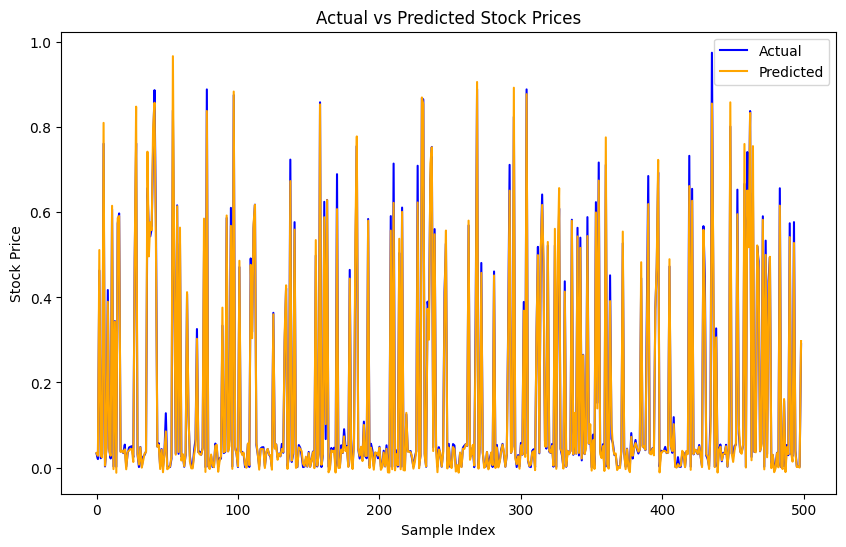

In [ ]:
import matplotlib.pyplot as plt

# Make predictions
y_pred = model.predict(X_test)

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label="Actual", color='blue')
plt.plot(y_pred, label="Predicted", color='orange')
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Sample Index")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

# Calculate R² score
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2}")

R² Score: 0.9917510021850011


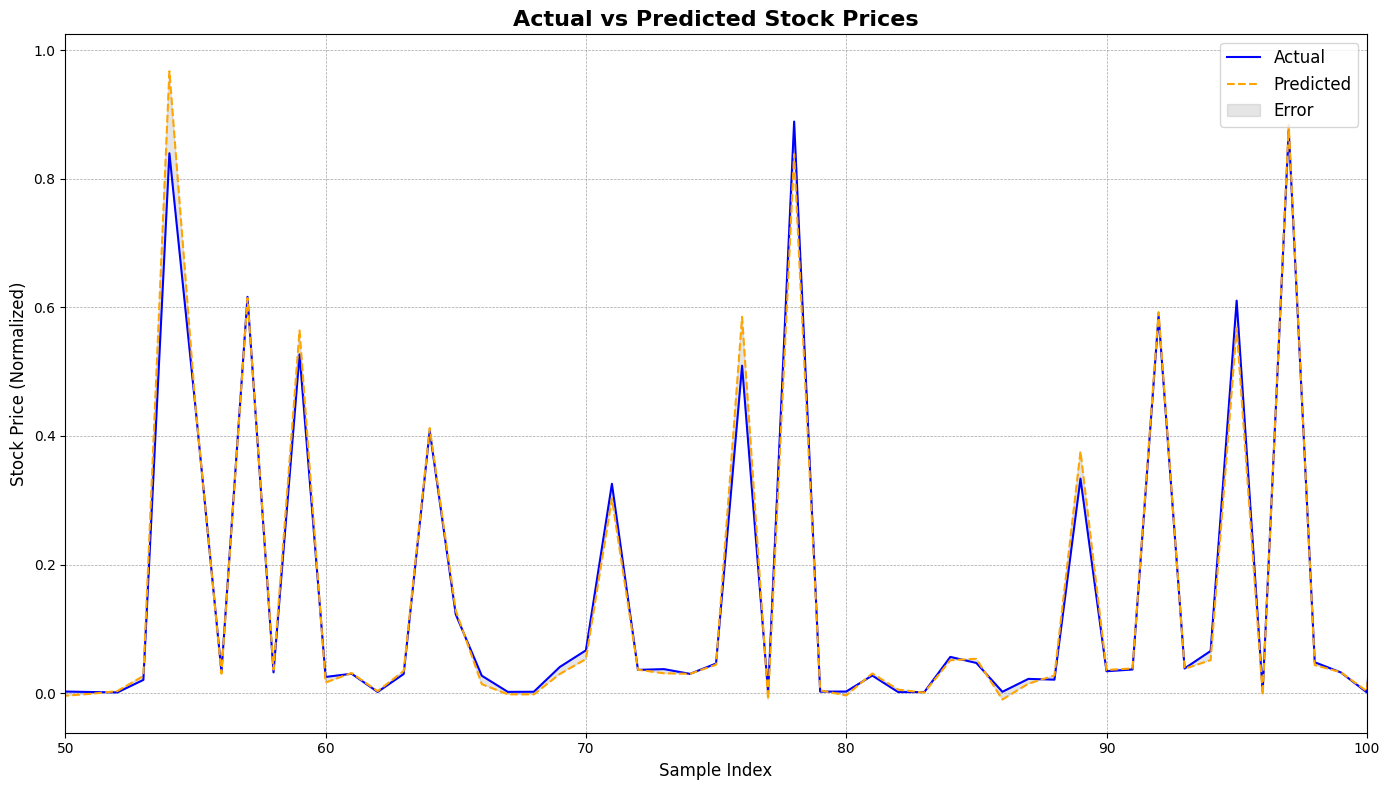

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create an index for plotting
index = np.arange(len(y_test))

# Plot actual vs predicted values
plt.figure(figsize=(14, 8))  # Increase figure size for better visibility
plt.plot(index, y_test, label="Actual", color='blue', linewidth=1.5)
plt.plot(index, y_pred, label="Predicted", color='orange', linestyle='--', linewidth=1.5)

# Add gridlines
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Highlight differences
plt.fill_between(index, y_test.flatten(), y_pred.flatten(), color='gray', alpha=0.2, label="Error")

# Title and labels
plt.title("Actual vs Predicted Stock Prices", fontsize=16, fontweight='bold')
plt.xlabel("Sample Index", fontsize=12)
plt.ylabel("Stock Price (Normalized)", fontsize=12)

# Add legend
plt.legend(loc="upper right", fontsize=12)

start, end = 50, 100  # Adjust range as needed
plt.xlim(start, end)  # Show detailed view of the specified range

# Display the plot
plt.tight_layout()
plt.show()